Exploratory data analysis of mitchell 2013 data (WAIS and GSIP2 methane concentrations). Test the following:

1. Is there a period of time after which it's necessary to mask for the trend in the data?
2. Is the power spectrum sensitive to the trend of the data?
3. Is there a significant difference between WAIS and GSIP2 power spectra?

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from hydra import initialize, compose
from pathlib import Path
from astropy.timeseries import LombScargle

In [ ]:
## load the data
with initialize(version_base=None, config_path="../../configs"):  # configs with data paths
    cfg = compose(config_name="config")
data_dir = Path(cfg.paths.observations_cultivated)

# load WDC05A, WDC06A, and GISP2 data
wais_wdc05a = pd.read_csv(data_dir / "mitchelletal2013_wdc05a.csv")
wais_wdc06a = pd.read_csv(data_dir / "mitchelletal2013_wdc06a.csv")
gisp2 = pd.read_csv(data_dir / "mitchelletal2013_gisp2.csv")

# rename columns
for df in [wais_wdc05a, wais_wdc06a, gisp2]:
    df.rename(
        columns={"gas_age_ce": "gas_age", "mean_concentration_ppb": "ch4"}, inplace=True
    )

In [67]:
## define parameters for plotting
colors = {
    "wais_wdc05a": "tab:blue",
    "wais_wdc06a": "tab:orange",
    "gisp2": "tab:green",
}
plot_kwargs = {
    "marker": "o",
    "markersize": 4,
    "linestyle": "None",
}
tick_periods = [1000, 500, 200, 100, 50, 20, 10]


## function for plotting power spectra
def plot_power_spectrum(
    ax,
    name_list,
    psd_dict,
    frequencies_dict,
    colors_dict=colors,
    tick_periods=tick_periods,
    mask_period=0,
    **plot_kwargs,
):
    for name in name_list:
        mask = 1 / frequencies_dict[name] > mask_period
        ax.plot(
            1 / frequencies_dict[name][mask],
            psd_dict[name][mask],
            label=name,
            color=colors_dict[name],
            alpha=0.6,
            **plot_kwargs,
        )
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("Period (years)")
    ax.set_ylabel("Power Spectral Density (ppb$^2$ year)")
    ax.legend()

    ax.set_xticks(tick_periods)
    ax.set_xticklabels(tick_periods)

Text(0, 0.5, 'CH$_4$ Concentration (ppb)')

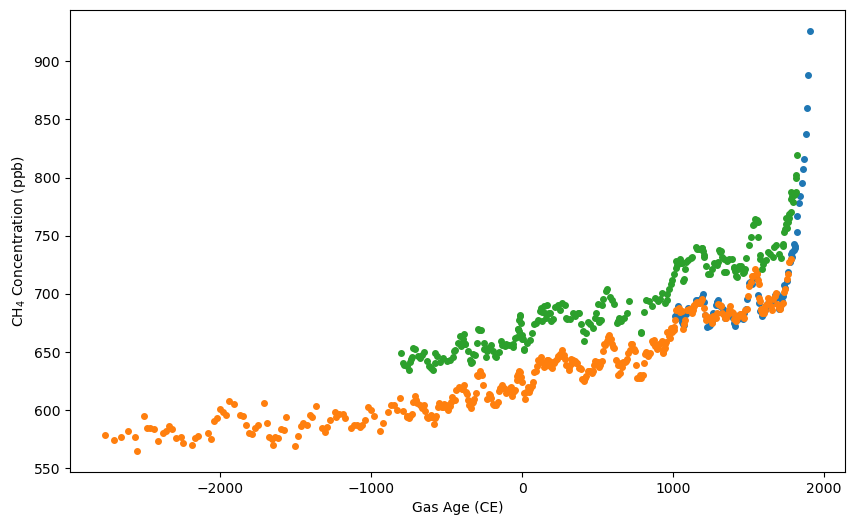

In [32]:
## plot all three datasets
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    wais_wdc05a["gas_age"],
    wais_wdc05a["ch4"],
    label="WDC05A",
    color=colors["wais_wdc05a"],
    **plot_kwargs,
)
ax.plot(
    wais_wdc06a["gas_age"],
    wais_wdc06a["ch4"],
    label="WDC06A",
    color=colors["wais_wdc06a"],
    **plot_kwargs,
)
ax.plot(
    gisp2["gas_age"], gisp2["ch4"], label="GISP2", color=colors["gisp2"], **plot_kwargs
)
ax.set_xlabel("Gas Age (CE)")
ax.set_ylabel("CH$_4$ Concentration (ppb)")

# calculate and compare power spectra of all three datasets

In [ ]:
frequencies = {}
psds = {}
for name, df in zip(
    ["wais_wdc05a", "wais_wdc06a", "gisp2"], [wais_wdc05a, wais_wdc06a, gisp2]
):
    # calculate Lomb-Scargle periodogram
    frequency, power = LombScargle(df["gas_age"], df["ch4"]).autopower(
        normalization="psd", samples_per_peak=1
    )
    frequencies[name] = frequency
    psds[name] = power

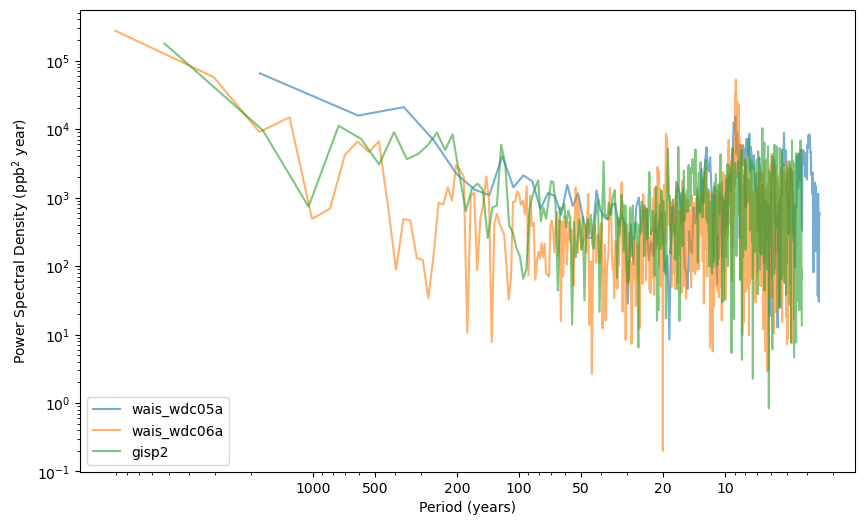

In [64]:
# plot power spectra
fig, ax = plt.subplots(figsize=(10, 6))
plot_power_spectrum(ax, ["wais_wdc05a", "wais_wdc06a", "gisp2"], psds, frequencies)

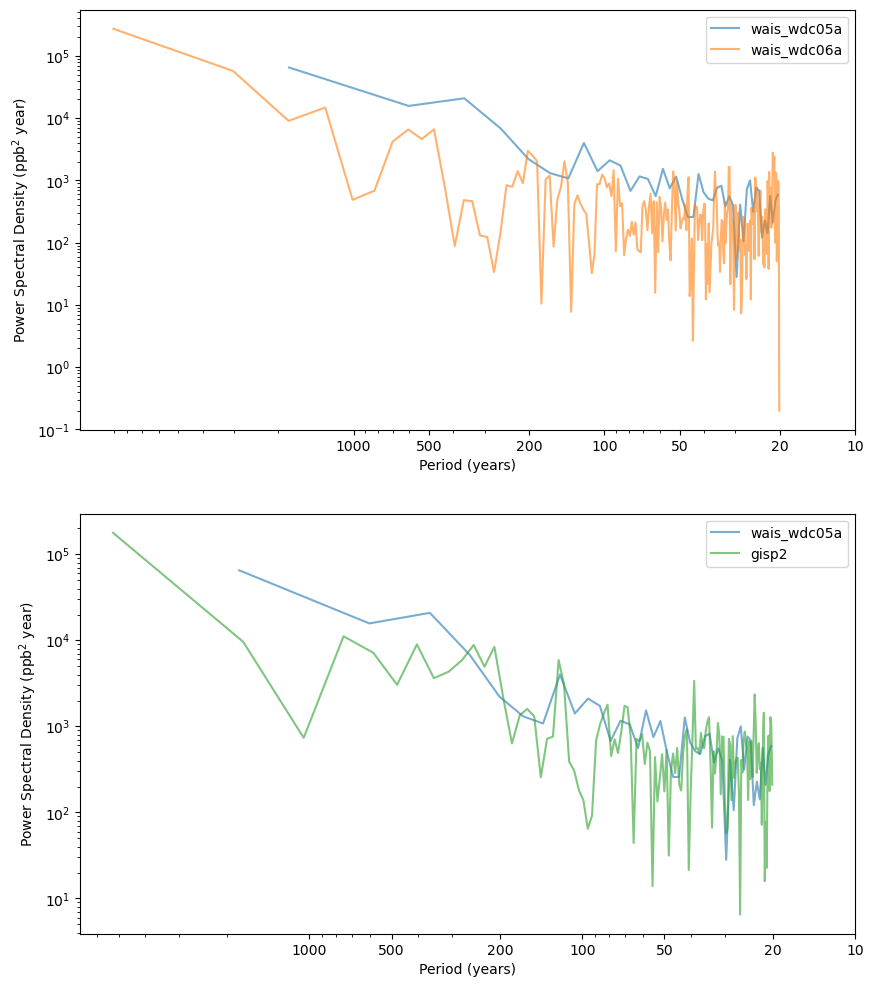

In [68]:
# plot power spectra with periods larger than 20 years, make 2 subplots
fig, (ax1, ax2) = plt.subplots(nrows=2, figsize=(10, 12))
xlim = (10000, 10)
# plot 1, compare only WAIS
plot_power_spectrum(
    ax1, ["wais_wdc05a", "wais_wdc06a"], psds, frequencies, mask_period=20
)

# plot 2, compare WAIS WDC05A and GISP2
plot_power_spectrum(ax2, ["wais_wdc05a", "gisp2"], psds, frequencies, mask_period=20)

GISP2 looks pretty similar to WDCO5A, but WDCO6A is different in terms of slope. I wonder if the long-term trend is causing some of the differences in the power spectra.

## detrend the data, then calculate and compare power spectra of all three datasets

In [58]:
trends = {}
frequencies_detrended = {}
psds_detrended = {}
for name, df in zip(
    ["wais_wdc05a", "wais_wdc06a", "gisp2"], [wais_wdc05a, wais_wdc06a, gisp2]
):
    # detrend the data
    trend = np.polyfit(df["gas_age"], df["ch4"], 1)
    trends[name] = trend
    df["ch4_detrended"] = df["ch4"] - (trend[0] * df["gas_age"] + trend[1])
    print(f"Detrended {name} with slope {trend[0]:.4f} ppb/year")

    # calculate Lomb-Scargle periodogram for detrended data
    frequency, power = LombScargle(df["gas_age"], df["ch4_detrended"]).autopower(
        normalization="psd", samples_per_peak=1
    )
    frequencies_detrended[name] = frequency
    psds_detrended[name] = power

Detrended wais_wdc05a with slope 0.1139 ppb/year
Detrended wais_wdc06a with slope 0.0317 ppb/year
Detrended gisp2 with slope 0.0479 ppb/year


Text(0, 0.5, 'Detrended CH$_4$ Concentration (ppb)')

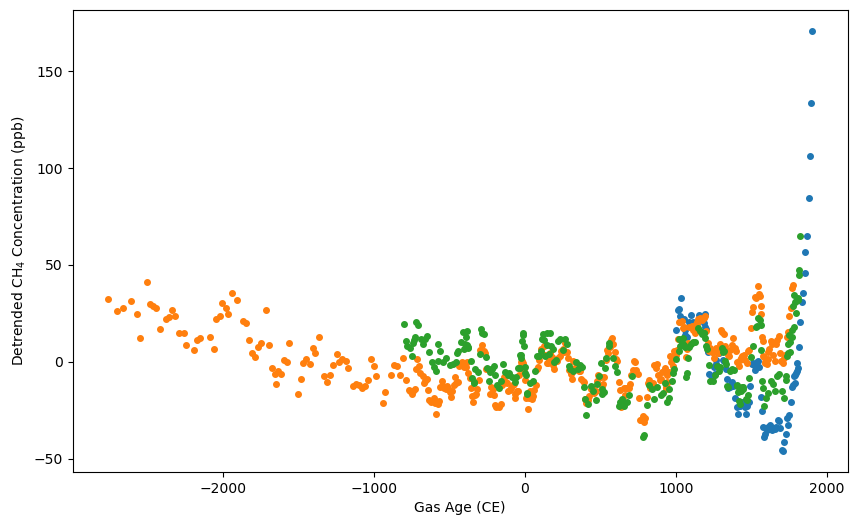

In [59]:
# plot detrended time series
fig, ax = plt.subplots(figsize=(10, 6))
for name, df in zip(
    ["wais_wdc05a", "wais_wdc06a", "gisp2"], [wais_wdc05a, wais_wdc06a, gisp2]
):
    ax.plot(
        df["gas_age"],
        df["ch4_detrended"],
        label=name,
        color=colors[name],
        **plot_kwargs,
    )
ax.set_xlabel("Gas Age (CE)")
ax.set_ylabel("Detrended CH$_4$ Concentration (ppb)")

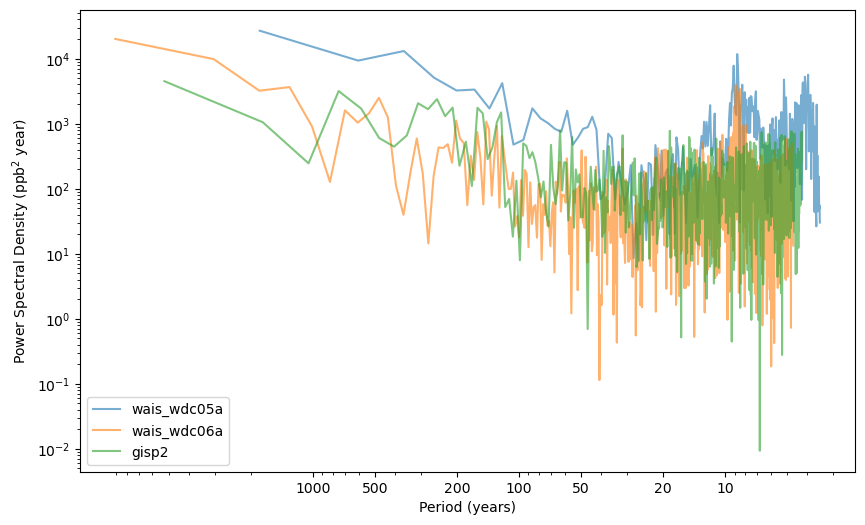

In [69]:
## plot detrended power spectra
fig, ax = plt.subplots(figsize=(10, 6))
plot_power_spectrum(
    ax, ["wais_wdc05a", "wais_wdc06a", "gisp2"], psds_detrended, frequencies_detrended
)

Slope of original WDC06A power spectrum: 0.7050
Slope of detrended WDC06A power spectrum: 0.9627


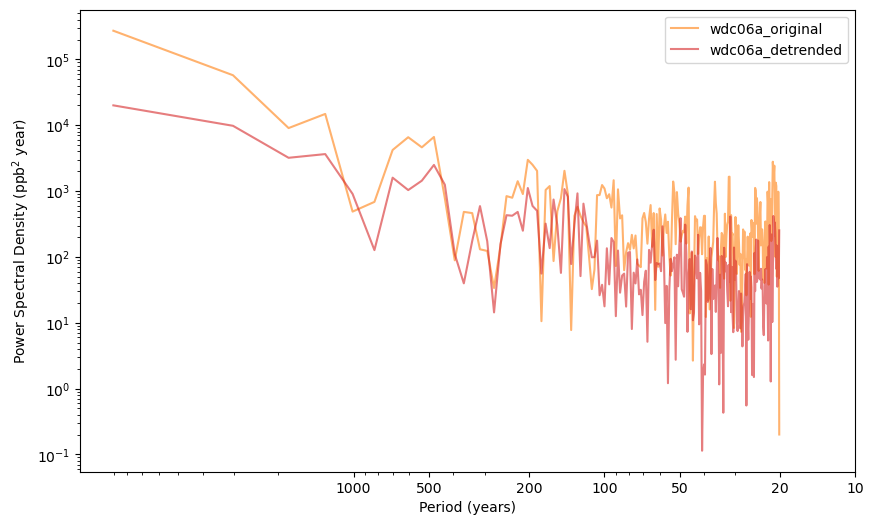

In [81]:
## plot detrended wais wdc06a against original
# make new plotting dictionary
frequency_plot = {
    "wdc06a_original": frequencies["wais_wdc06a"],
    "wdc06a_detrended": frequencies_detrended["wais_wdc06a"],
}
psds_plot = {
    "wdc06a_original": psds["wais_wdc06a"],
    "wdc06a_detrended": psds_detrended["wais_wdc06a"],
}
fig, ax = plt.subplots(figsize=(10, 6))
plot_power_spectrum(
    ax,
    ["wdc06a_original", "wdc06a_detrended"],
    psds_plot,
    frequency_plot,
    colors_dict={
        "wdc06a_original": colors["wais_wdc06a"],
        "wdc06a_detrended": "tab:red",
    },
    mask_period=20,
)

# print the slope of the power spectra for both original and detrended WDC06A
mask = 1 / frequencies["wais_wdc06a"] > 20
slope_original = np.polyfit(
    np.log(1 / frequencies["wais_wdc06a"][mask]), np.log(psds["wais_wdc06a"][mask]), 1
)[0]
slope_detrended = np.polyfit(
    np.log(1 / frequencies_detrended["wais_wdc06a"][mask]),
    np.log(psds_detrended["wais_wdc06a"][mask]),
    1,
)[0]
print(f"Slope of original WDC06A power spectrum: {slope_original:.4f}")
print(f"Slope of detrended WDC06A power spectrum: {slope_detrended:.4f}")

Detrending changes the power and the slope of the power spectrum slightly.

(10000.0, 10.0)

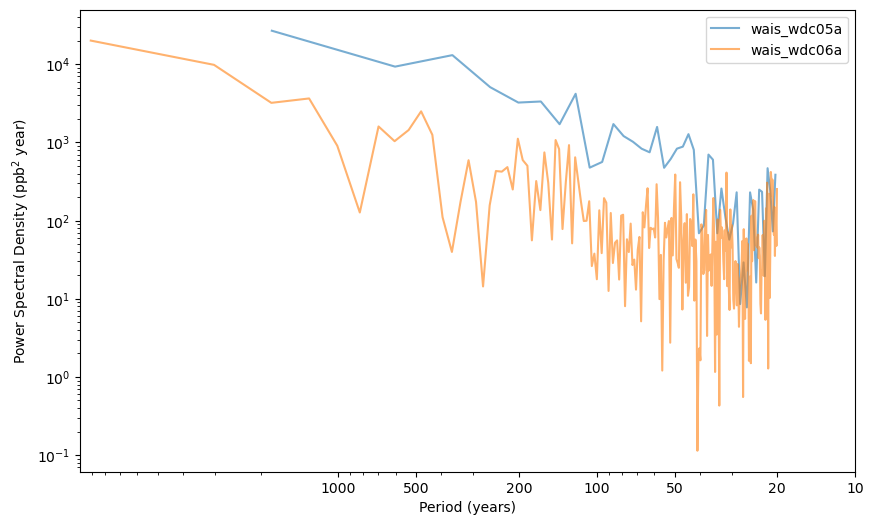

In [61]:
## plot just the WAIS data with detrended power spectra in periods larger than 20 years
fig, ax = plt.subplots(figsize=(10, 6))
for name in ["wais_wdc05a", "wais_wdc06a"]:
    mask = 1 / frequencies_detrended[name] > 20
    ax.plot(
        1 / frequencies_detrended[name][mask],
        psds_detrended[name][mask],
        label=name,
        color=colors[name],
        alpha=0.6,
    )
ax.set_xscale("log")
ax.set_yscale("log")
ax.invert_xaxis()
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power Spectral Density (ppb$^2$ year)")
ax.legend()

ax.set_xticks(tick_periods)
ax.set_xticklabels(tick_periods)
ax.set_xlim((10000, 10))

WDC05A still looks a little weird compared to WDC06A. I'm going to try removing the data in WDC05A past the end of WDC06A to see if that makes a difference.

## comparing WAIS data

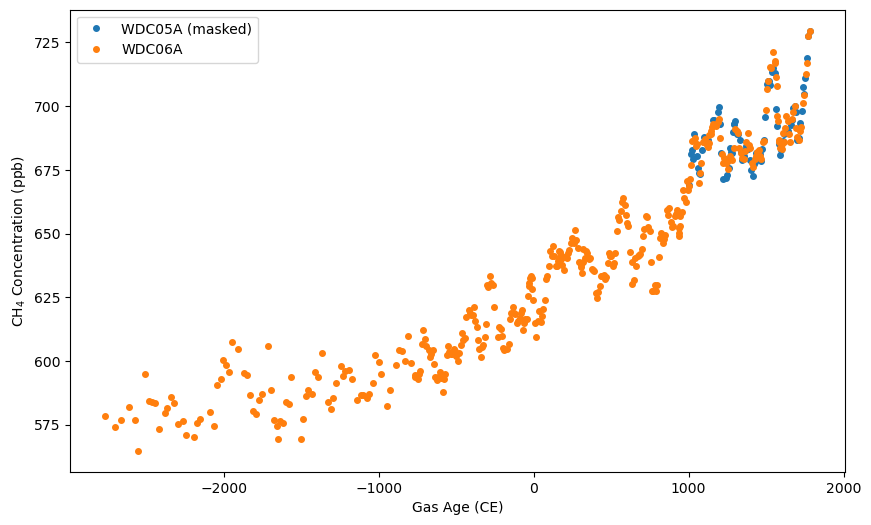

In [77]:
# mask data in WDC05A that is past the WDC06A end
mask = wais_wdc05a["gas_age"] <= wais_wdc06a["gas_age"].max()
wais_wdc05a_masked = wais_wdc05a[mask]
# plot the masked WDC05A data
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(
    wais_wdc05a_masked["gas_age"],
    wais_wdc05a_masked["ch4"],
    label="WDC05A (masked)",
    color=colors["wais_wdc05a"],
    **plot_kwargs,
)
ax.plot(
    wais_wdc06a["gas_age"],
    wais_wdc06a["ch4"],
    label="WDC06A",
    color=colors["wais_wdc06a"],
    **plot_kwargs,
)
ax.set_xlabel("Gas Age (CE)")
ax.set_ylabel("CH$_4$ Concentration (ppb)")
ax.legend()

In [82]:
# calculate power and frequency for the masked WDC05A
frequency_wdc05a_masked, power_masked = LombScargle(
    wais_wdc05a_masked["gas_age"], wais_wdc05a_masked["ch4"]
).autopower(normalization="psd", samples_per_peak=1)
frequency_plot["wdc05a_original"] = frequencies["wais_wdc05a"]
psds_plot["wdc05a_original"] = psds["wais_wdc05a"]
frequency_plot["wdc05a_masked"] = frequency_wdc05a_masked
psds_plot["wdc05a_masked"] = power_masked

Slope of WDC05A Masked power spectrum: 1.1603
Slope of WDC06A Detrended power spectrum: 0.9627


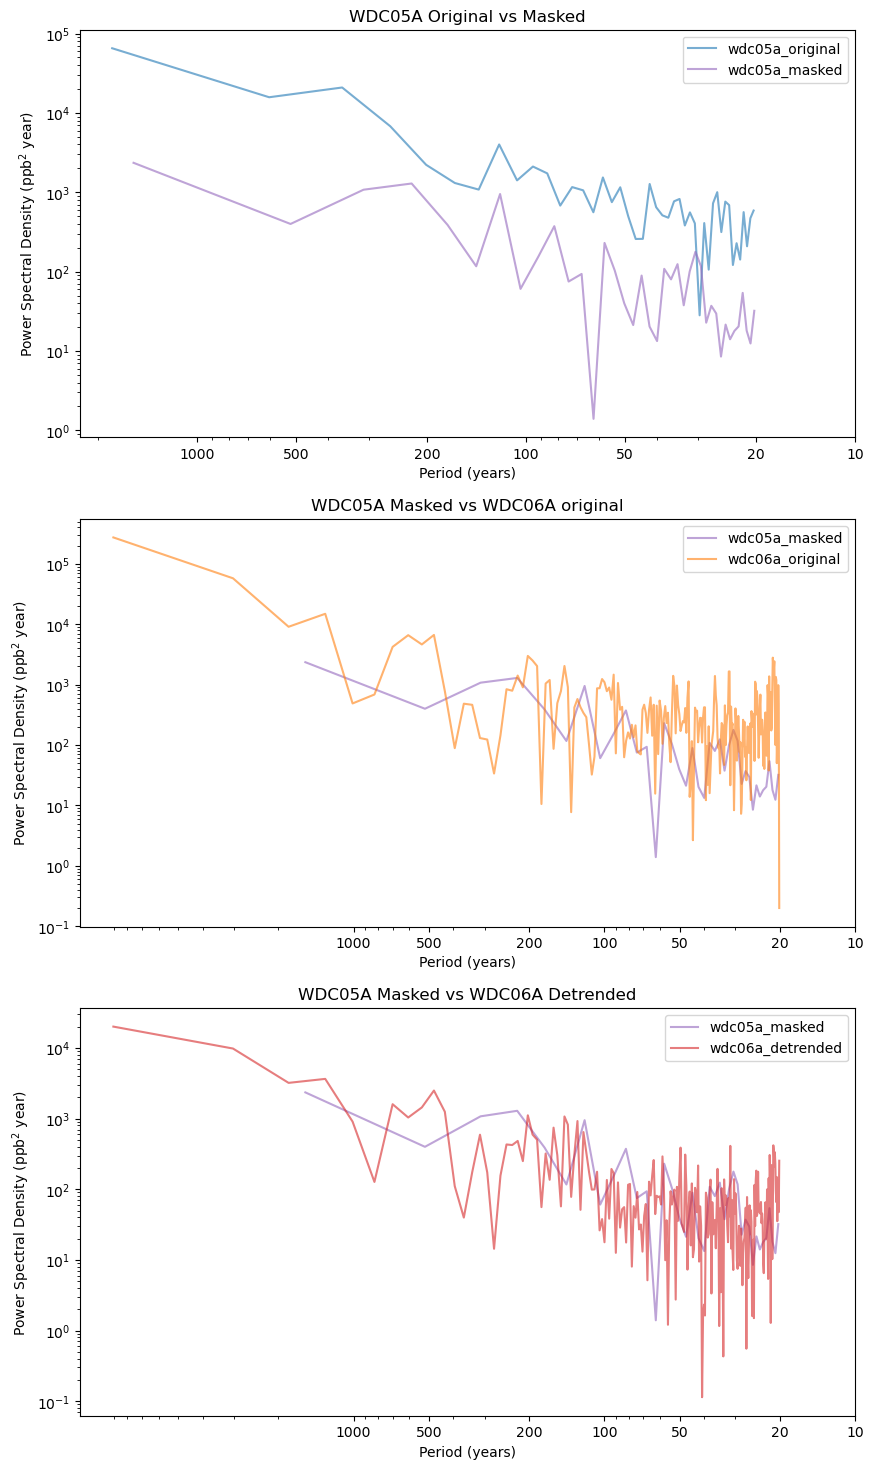

In [88]:
# compare in 3 subplots, plot original and masked WDC05A, masked WDC05A and WDC06A, then masked WDC05A and detrended WDC06A
fig, (ax1, ax2, ax3) = plt.subplots(nrows=3, figsize=(10, 18))
# plot 1: original and masked WDC05A
plot_power_spectrum(
    ax1,
    ["wdc05a_original", "wdc05a_masked"],
    psds_plot,
    frequency_plot,
    colors_dict={
        "wdc05a_original": colors["wais_wdc05a"],
        "wdc05a_masked": "tab:purple",
    },
    mask_period=20,
)
ax1.set_title("WDC05A Original vs Masked")
# plot 2: masked WDC05A and WDC06A
plot_power_spectrum(
    ax2,
    ["wdc05a_masked", "wdc06a_original"],
    psds_plot,
    frequency_plot,
    colors_dict={
        "wdc05a_masked": "tab:purple",
        "wdc06a_original": colors["wais_wdc06a"],
    },
    mask_period=20,
)
ax2.set_title("WDC05A Masked vs WDC06A original")
# plot 3: masked WDC05A and detrended WDC06A
plot_power_spectrum(
    ax3,
    ["wdc05a_masked", "wdc06a_detrended"],
    psds_plot,
    frequency_plot,
    colors_dict={"wdc05a_masked": "tab:purple", "wdc06a_detrended": "tab:red"},
    mask_period=20,
)
ax3.set_title("WDC05A Masked vs WDC06A Detrended")

# print regression of WDC05A Masked vs WDC06A Detrended
mask = 1 / frequency_wdc05a_masked > 20
slope_wdc05a_masked = np.polyfit(
    np.log(1 / frequency_wdc05a_masked[mask]), np.log(power_masked[mask]), 1
)[0]
mask = 1 / frequencies_detrended["wais_wdc06a"] > 20
slope_wdc06a_detrended = np.polyfit(
    np.log(1 / frequencies_detrended["wais_wdc06a"][mask]),
    np.log(psds_detrended["wais_wdc06a"][mask]),
    1,
)[0]
print(f"Slope of WDC05A Masked power spectrum: {slope_wdc05a_masked:.4f}")
print(f"Slope of WDC06A Detrended power spectrum: {slope_wdc06a_detrended:.4f}")